In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

nav['date'] = pd.to_datetime(
    nav['date']
)

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
selected_funds = (
    nav['amfi_code']
    .unique()[:5]
)

print("Selected Funds:")
print(selected_funds)

Selected Funds:
[100016 100025 100033 101206 101207]


In [4]:
returns = (
    nav[
        nav['amfi_code']
        .isin(selected_funds)
    ]
    .pivot(
        index='date',
        columns='amfi_code',
        values='daily_return'
    )
)

returns = returns.dropna()

returns.head()

amfi_code,100016,100025,100033,101206,101207
date,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251


In [5]:
mean_returns = (
    returns.mean() * 252
)

cov_matrix = (
    returns.cov() * 252
)

print(mean_returns)

amfi_code
100016    0.035683
100025    0.042854
100033    0.272111
101206    0.214647
101207    0.106962
dtype: float64


In [6]:
num_portfolios = 5000

results = []

for _ in range(num_portfolios):

    weights = np.random.random(
        len(selected_funds)
    )

    weights /= np.sum(weights)

    portfolio_return = np.sum(
        weights * mean_returns
    )

    portfolio_risk = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix,
                weights
            )
        )
    )

    sharpe_ratio = (
        portfolio_return /
        portfolio_risk
    )

    results.append([
        portfolio_return,
        portfolio_risk,
        sharpe_ratio
    ])

results = np.array(results)

print(results.shape)

(5000, 3)


In [7]:
max_sharpe_idx = np.argmax(
    results[:,2]
)

best_portfolio = results[
    max_sharpe_idx
]

print("Best Portfolio")

print(
    "Expected Return:",
    round(best_portfolio[0],4)
)

print(
    "Risk:",
    round(best_portfolio[1],4)
)

print(
    "Sharpe Ratio:",
    round(best_portfolio[2],4)
)

Best Portfolio
Expected Return: 0.1363
Risk: 0.0584
Sharpe Ratio: 2.3344


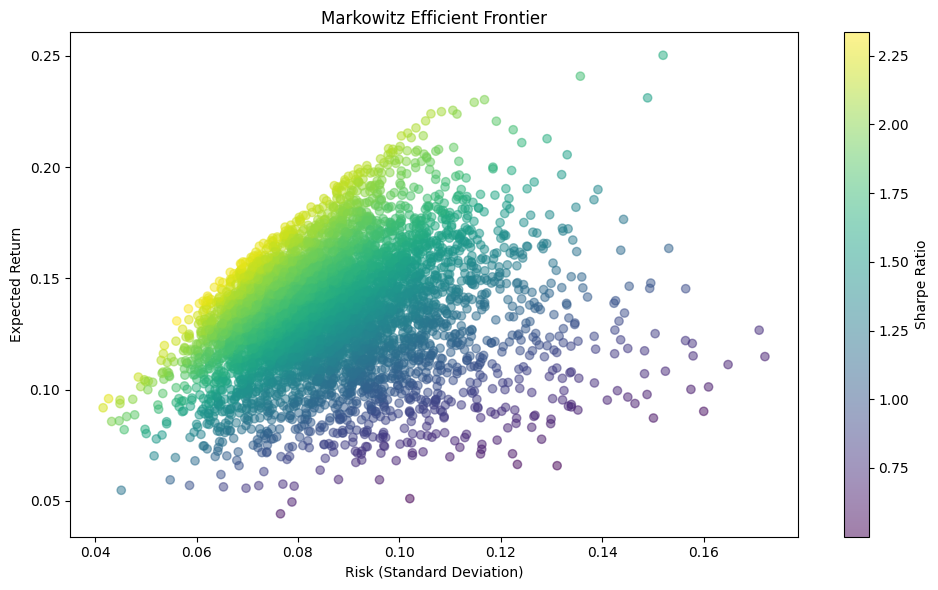

In [8]:
plt.figure(figsize=(10,6))

plt.scatter(
    results[:,1],
    results[:,0],
    c=results[:,2],
    alpha=0.5
)

plt.colorbar(
    label="Sharpe Ratio"
)

plt.xlabel(
    "Risk (Standard Deviation)"
)

plt.ylabel(
    "Expected Return"
)

plt.title(
    "Markowitz Efficient Frontier"
)

plt.tight_layout()

plt.savefig(
    "../reports/efficient_frontier.png"
)

plt.show()

# Portfolio Optimization Insights

1. Generated 5000 random portfolio combinations using five mutual funds.

2. Calculated annualized return, portfolio risk and Sharpe Ratio.

3. Efficient Frontier demonstrates the trade-off between risk and return.

4. Higher Sharpe Ratio portfolios provide better risk-adjusted performance.

5. Investors can use this framework to identify diversified portfolios that maximize expected return for a given level of risk.